Here this is showing that how we can have previous valuses and the operation performed on it to get the final result.


In [2]:
import math

In [3]:
class Value:
    def __init__(self,data,_children=(),_op="",label=""):
        self.data=data
        self._prev=set(_children)
        self._op=_op
        self.label=label
        self.grad=0
    def __repr__(self):
        return f"value(data={self.data})"
    
    def __add__(self,other):
        out=Value(self.data+other.data,(self,other),"+")
        return out

    def __mul__(self,other):
        out=Value(self.data*other.data,(self,other),"*")
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) -1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), "tanh")
        return out

a=Value(2.0,label="a")
b=Value(-3.0,label="b")
c=Value(10.0,label="c")
e=a*b; e.label="e"
d=e+c; d.label="d"
f=Value(-2.0,label="f")
L=d*f;L.label="L"
#d=a*b +c # this work like a.__mul__(b).__add__(c)
L

value(data=-8.0)

In [4]:
d._prev

{value(data=-6.0), value(data=10.0)}

In [5]:
d._op

'+'

In [6]:
!pip install graphviz
!pip install numpy matplotlib

In [7]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [8]:
L.grad=1.0

Now we will find the derivative of L w.r.t d and f.
<br>dL/dd=f and dL/df=d


In [9]:
f.grad=4
d.grad=-2

Now we will find derivate of L w.r.t c and e <br>
d=e+c and L=d*f and  dd/dc=1  and dd/de=1 <br>
dL/dc = dL/dd * dL/dc (chain rule)<br>
hence, dL/dc=f*1 = f = -2.<br>
and, dL/de = -2 .


In [10]:
c.grad=-2.0
e.grad=-2.0

Now we will do the same for a and b. <br>
e=a*b and d=e+c and L=d*f , and de/da = b and de/db = a <br>
hence, dL/da = dL/dd * dd/de * de/da = f * 1 * b = -2 * 1 * -3 = 6.<br> 
and , dL/db = dL/dd * dd/de * de/da = f * 1 * a = -2 * 1 * 2 = -4

In [11]:
a.grad=6
b.grad=-4

In [12]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e=a*b 
d=e+c
L=d*f
print(L.data)

-7.286496


In [13]:
def lol() :
    h=0.001
    a=Value(2.0,label="a")
    b=Value(-3.0,label="b")
    c=Value(10.0,label="c")
    e=a*b; e.label="e"
    d=e+c; d.label="d"
    f=Value(-2.0,label="f")
    L=d*f;L.label="L"
    L1=L.data

    a=Value(2.0 ,label="a")
    b=Value(-3.0,label="b")
    b.data += h
    c=Value(10.0,label="c")
    e=a*b; e.label="e"
    d=e+c; d.label="d"
    f=Value(-2.0,label="f")
    L=d*f;L.label="L"
    L2=L.data 
    print((L2-L1)/h)

lol()


-3.9999999999995595


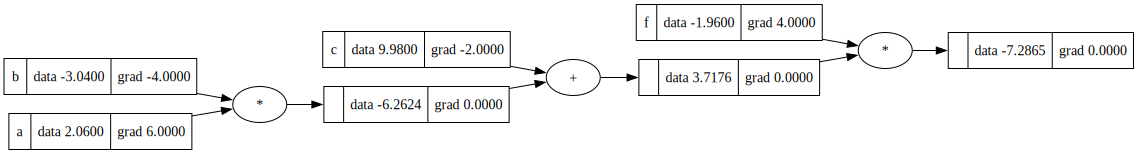

In [14]:
draw_dot(L)

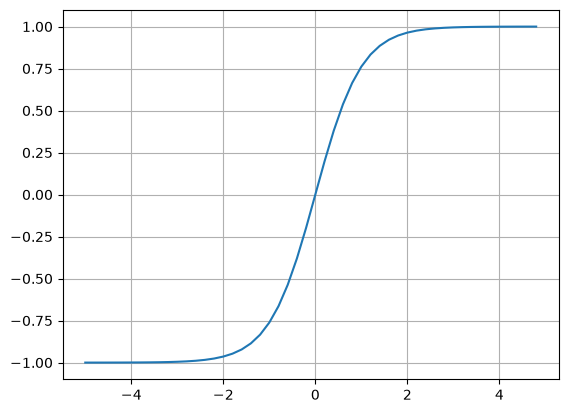

In [15]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)));plt.grid();

Now we are going to create a neuron and do the backpropagation on it.

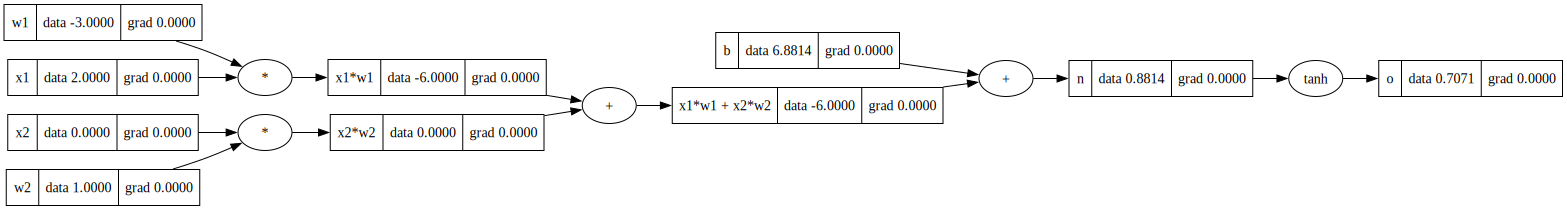

In [16]:
# inputs 
x1 = Value(2.0,label="x1")
x2 = Value(0.0,label="x2")
# weights 
w1=Value(-3.0,label="w1")
w2=Value(1.0,label="w2")
#bias of the neuron
b=Value(6.8813735870195432,label="b")
# weighted sum with bias i.e x1w1 + x2w2 + b
x1w1 = x1*w1 ; x1w1.label = "x1*w1" 
x2w2 = x2*w2 ; x2w2.label = "x2*w2"
x1w1x2w2 = x1w1 + x2w2  ; x1w1x2w2.label = "x1*w1 + x2*w2"
n = x1w1x2w2 + b ; n.label = "n"
o = n.tanh() ; o.label = "o"

draw_dot(o)

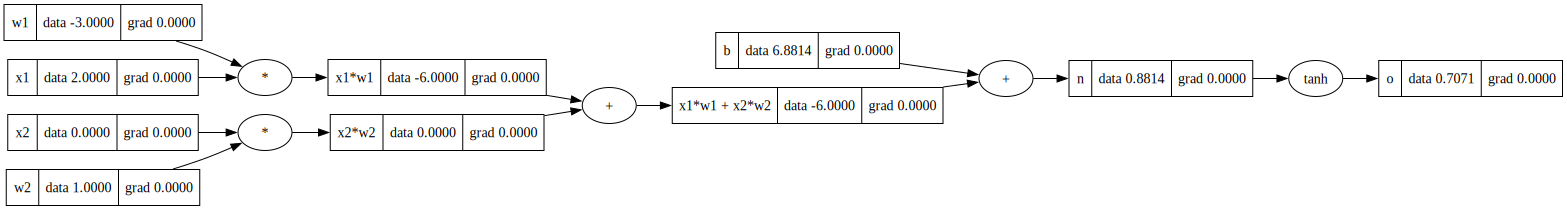

In [17]:
draw_dot(o)